In [1]:
import torch
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
import random
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from tqdm import tqdm
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

In [2]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(42)

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo de processamento: {device}")

Dispositivo de processamento: cuda


In [4]:
transform = transforms.Compose(
    [transforms.Grayscale(num_output_channels=1), transforms.ToTensor()]
)

caminho_dataset = "dataset/ORL/"
dataset_completo = datasets.ImageFolder(root=caminho_dataset, transform=transform)

indices = np.arange(len(dataset_completo))
alvos = dataset_completo.targets
idx_treino, idx_teste = train_test_split(
    indices, test_size=0.3, stratify=alvos, random_state=42
)

In [5]:
dataset_treino = Subset(dataset_completo, idx_treino)
dataset_teste = Subset(dataset_completo, idx_teste)

print(f"Total de amostras originais: {len(dataset_completo)}")
print(f"Imagens para treinamento (70%): {len(dataset_treino)}")
print(f"Imagens para teste (30%): {len(dataset_teste)}")

Total de amostras originais: 400
Imagens para treinamento (70%): 280
Imagens para teste (30%): 120


In [6]:
TAMANHO_LOTE = 32

loader_treino = DataLoader(dataset_treino, batch_size=TAMANHO_LOTE, shuffle=True)
loader_teste = DataLoader(dataset_teste, batch_size=TAMANHO_LOTE, shuffle=False)

In [7]:
def imshow(img, title=None):
    npimg = img.numpy()
    plt.figure(figsize=(12, 6))
    plt.imshow(np.transpose(npimg, (1, 2, 0)), cmap="gray")
    if title:
        plt.title(title, fontsize=14, pad=15)
    plt.axis("off")
    plt.show()


imagens_exemplo, rotulos_exemplo = next(iter(loader_treino))

print(
    f"Formato do tensor (lote) de imagens: {imagens_exemplo.shape} -> (Lote, Canais, Altura, Largura)"
)
print(f"Formato do tensor (lote) de rótulos: {rotulos_exemplo.shape}")

Formato do tensor (lote) de imagens: torch.Size([32, 1, 112, 92]) -> (Lote, Canais, Altura, Largura)
Formato do tensor (lote) de rótulos: torch.Size([32])


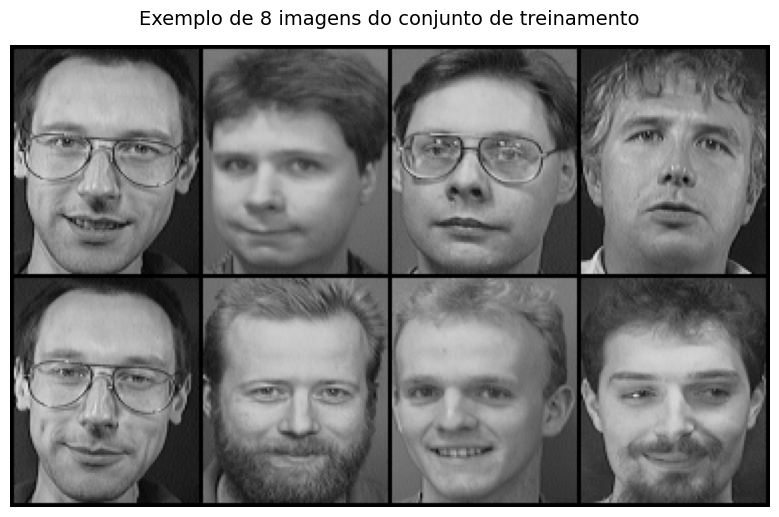

In [8]:
out = torchvision.utils.make_grid(imagens_exemplo[:8], nrow=4)
imshow(out, title="Exemplo de 8 imagens do conjunto de treinamento")

In [9]:
class CNN_Arquitetura1(nn.Module):
    def __init__(self, num_classes=40):
        super(CNN_Arquitetura1, self).__init__()

        self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1)
        self.batch1 = nn.BatchNorm2d(16)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.flatten_size = 16 * 56 * 46

        self.fc1 = nn.Linear(in_features=self.flatten_size, out_features=num_classes)

    def forward(self, x):
        x = self.conv1(x)
        x = self.batch1(x)
        x = F.relu(x)
        x = self.pool1(x)

        x = x.view(x.size(0), -1)

        x = self.fc1(x)
        return x


modelo_arq1 = CNN_Arquitetura1(num_classes=40).to(device)

Iniciando Treinamento da Arquitetura 1...
Epoca [1/30] | Acc Treino: 18.57% | Acc Teste: 5.83%
Epoca [5/30] | Acc Treino: 95.00% | Acc Teste: 83.33%
Epoca [10/30] | Acc Treino: 100.00% | Acc Teste: 92.50%
Epoca [15/30] | Acc Treino: 100.00% | Acc Teste: 93.33%
Epoca [20/30] | Acc Treino: 100.00% | Acc Teste: 93.33%
Epoca [25/30] | Acc Treino: 100.00% | Acc Teste: 93.33%
Epoca [30/30] | Acc Treino: 100.00% | Acc Teste: 93.33%


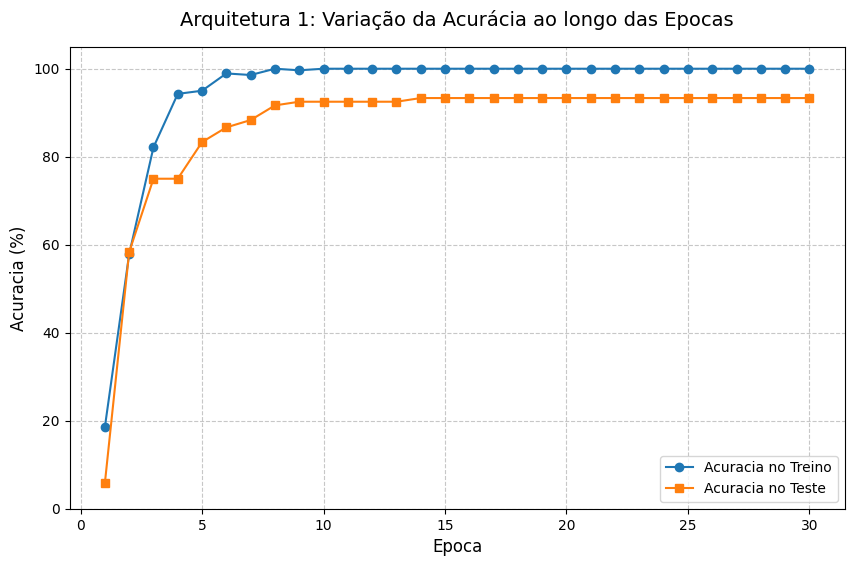

Resultado Final (Arquitetura 1) -> Acurácia no Teste: 93.33%


In [10]:
criterio = nn.CrossEntropyLoss()
otimizador = optim.Adam(modelo_arq1.parameters(), lr=0.001)
epocas = 30

historico_acc_treino = []
historico_acc_teste = []

print("Iniciando Treinamento da Arquitetura 1...")

for epoca in range(epocas):
    modelo_arq1.train()
    acertos_treino = 0
    total_treino = 0

    for imagens, rotulos in loader_treino:
        imagens, rotulos = imagens.to(device), rotulos.to(device)

        otimizador.zero_grad()
        saidas = modelo_arq1(imagens)
        erro = criterio(saidas, rotulos)

        erro.backward()
        otimizador.step()

        _, previstos = torch.max(saidas.data, 1)
        total_treino += rotulos.size(0)
        acertos_treino += (previstos == rotulos).sum().item()

    acc_treino = 100 * acertos_treino / total_treino
    historico_acc_treino.append(acc_treino)

    modelo_arq1.eval()
    acertos_teste = 0
    total_teste = 0

    with torch.no_grad():
        for imagens, rotulos in loader_teste:
            imagens, rotulos = imagens.to(device), rotulos.to(device)
            saidas = modelo_arq1(imagens)
            _, previstos = torch.max(saidas.data, 1)
            total_teste += rotulos.size(0)
            acertos_teste += (previstos == rotulos).sum().item()

    acc_teste = 100 * acertos_teste / total_teste
    historico_acc_teste.append(acc_teste)

    if (epoca + 1) % 5 == 0 or epoca == 0:
        print(
            f"Epoca [{epoca + 1}/{epocas}] | Acc Treino: {acc_treino:.2f}% | Acc Teste: {acc_teste:.2f}%"
        )

plt.figure(figsize=(10, 6))
plt.plot(
    range(1, epocas + 1),
    historico_acc_treino,
    label="Acuracia no Treino",
    color="#1f77b4",
    marker="o",
)
plt.plot(
    range(1, epocas + 1),
    historico_acc_teste,
    label="Acuracia no Teste",
    color="#ff7f0e",
    marker="s",
)
plt.title(
    "Arquitetura 1: Variação da Acurácia ao longo das Epocas", fontsize=14, pad=15
)
plt.xlabel("Epoca", fontsize=12)
plt.ylabel("Acuracia (%)", fontsize=12)
plt.ylim(0, 105)
plt.grid(True, linestyle="--", alpha=0.7)
plt.legend(loc="lower right")
plt.show()

print(
    f"Resultado Final (Arquitetura 1) -> Acurácia no Teste: {historico_acc_teste[-1]:.2f}%"
)

Relatório de classificação - Arquitetura 1
              precision    recall  f1-score   support

           0       0.67      0.67      0.67         3
           1       1.00      1.00      1.00         3
           2       1.00      1.00      1.00         3
           3       1.00      1.00      1.00         3
           4       1.00      1.00      1.00         3
           5       1.00      1.00      1.00         3
           6       1.00      1.00      1.00         3
           7       1.00      0.33      0.50         3
           8       1.00      1.00      1.00         3
           9       1.00      0.67      0.80         3
          10       0.75      1.00      0.86         3
          11       1.00      1.00      1.00         3
          12       1.00      1.00      1.00         3
          13       1.00      1.00      1.00         3
          14       1.00      1.00      1.00         3
          15       1.00      1.00      1.00         3
          16       1.00      1.00     

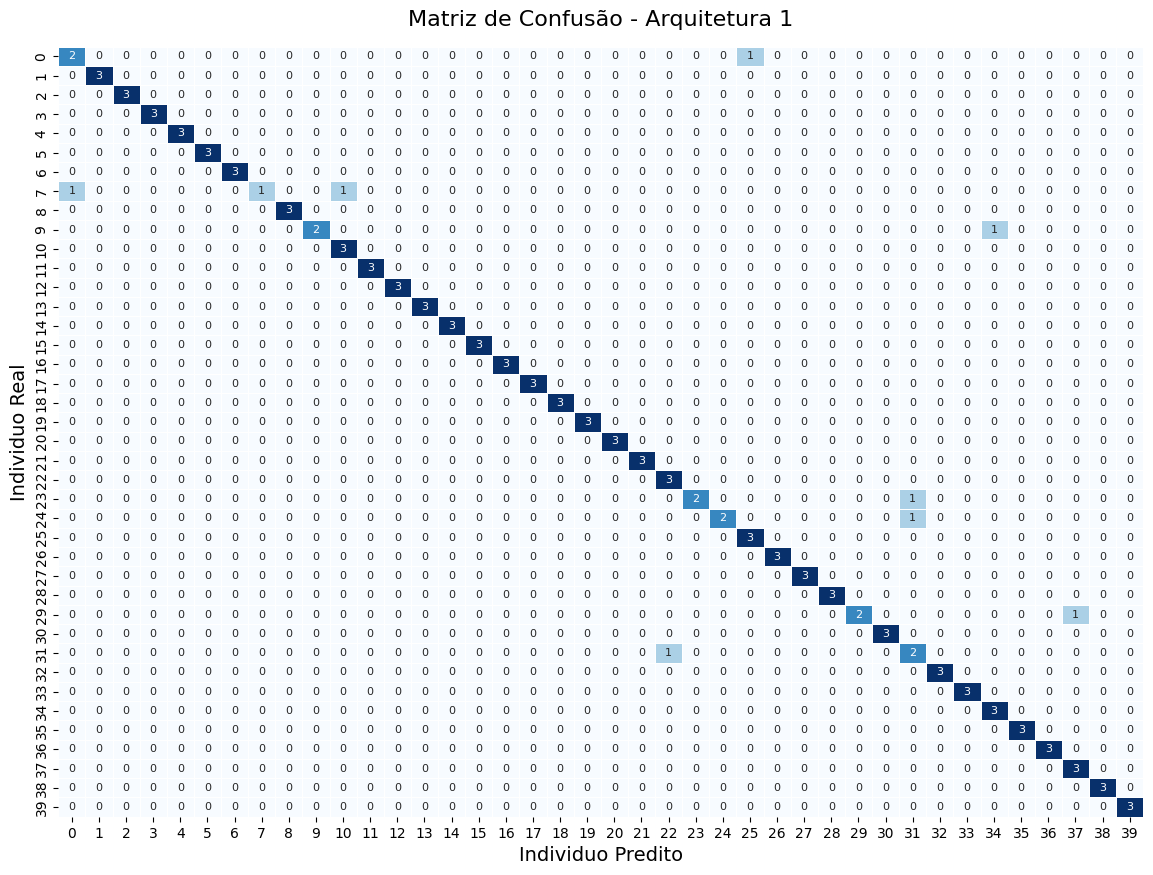

In [11]:
todas_preds_arq1 = []
todos_rotulos_arq1 = []

modelo_arq1.eval()
with torch.no_grad():
    for imagens, rotulos in loader_teste:
        imagens = imagens.to(device)
        saidas = modelo_arq1(imagens)
        _, previstos = torch.max(saidas, 1)

        todas_preds_arq1.extend(previstos.cpu().numpy())
        todos_rotulos_arq1.extend(rotulos.numpy())

print("Relatório de classificação - Arquitetura 1")
print(classification_report(todos_rotulos_arq1, todas_preds_arq1, zero_division=0))

matriz_conf_arq1 = confusion_matrix(todos_rotulos_arq1, todas_preds_arq1)

plt.figure(figsize=(14, 10))

sns.heatmap(
    matriz_conf_arq1,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    annot_kws={"size": 8},
    linewidths=0.5,
)
plt.title("Matriz de Confusão - Arquitetura 1", fontsize=16, pad=15)
plt.ylabel("Individuo Real", fontsize=14)
plt.xlabel("Individuo Predito", fontsize=14)
plt.show()

In [12]:
class CNN_Arquitetura2(nn.Module):
    def __init__(self, num_classes=40):
        super(CNN_Arquitetura2, self).__init__()

        self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1)
        self.batch1 = nn.BatchNorm2d(16)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv2 = nn.Conv2d(
            in_channels=16, out_channels=32, kernel_size=3, padding=1
        )
        self.batch2 = nn.BatchNorm2d(32)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv3 = nn.Conv2d(
            in_channels=32, out_channels=64, kernel_size=3, padding=1
        )
        self.batch3 = nn.BatchNorm2d(64)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.flatten_size = 64 * 14 * 11

        self.fc1 = nn.Linear(in_features=self.flatten_size, out_features=num_classes)

    def forward(self, x):
        x = self.pool1(F.relu(self.batch1(self.conv1(x))))
        x = self.pool2(F.relu(self.batch2(self.conv2(x))))
        x = self.pool3(F.relu(self.batch3(self.conv3(x))))

        x = x.view(x.size(0), -1)

        x = self.fc1(x)
        return x


modelo_arq2 = CNN_Arquitetura2(num_classes=40).to(device)

Iniciando Treinamento da Arquitetura 2...
Epoca [1/30] | Acc Treino: 23.57% | Acc Teste: 6.67%
Epoca [5/30] | Acc Treino: 100.00% | Acc Teste: 50.83%
Epoca [10/30] | Acc Treino: 100.00% | Acc Teste: 99.17%
Epoca [15/30] | Acc Treino: 100.00% | Acc Teste: 99.17%
Epoca [20/30] | Acc Treino: 100.00% | Acc Teste: 99.17%
Epoca [25/30] | Acc Treino: 100.00% | Acc Teste: 99.17%
Epoca [30/30] | Acc Treino: 100.00% | Acc Teste: 99.17%


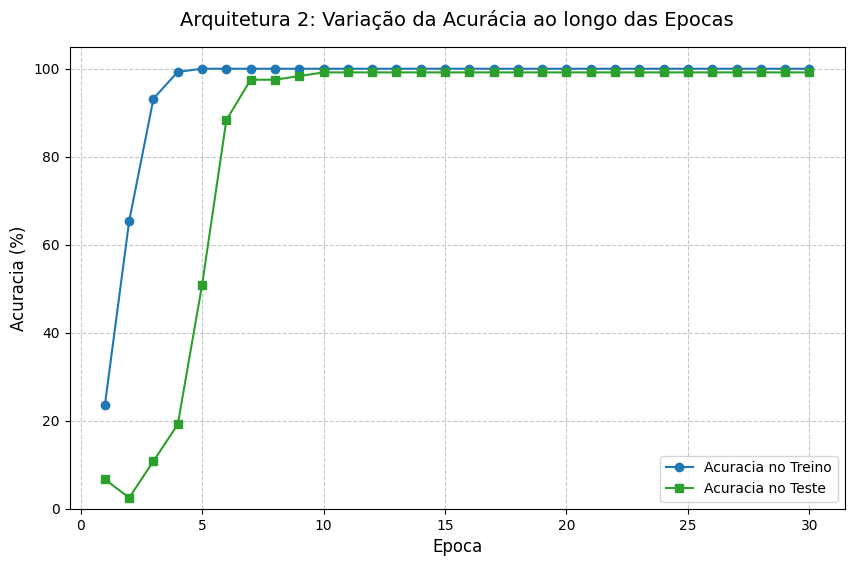

Resultado Final (Arquitetura 2) -> Acurácia no Teste: 99.17%


In [13]:
criterio = nn.CrossEntropyLoss()
otimizador2 = optim.Adam(modelo_arq2.parameters(), lr=0.001)
epocas = 30

historico_acc_treino2 = []
historico_acc_teste2 = []

print("Iniciando Treinamento da Arquitetura 2...")

for epoca in range(epocas):
    modelo_arq2.train()
    acertos_treino = 0
    total_treino = 0

    for imagens, rotulos in loader_treino:
        imagens, rotulos = imagens.to(device), rotulos.to(device)

        otimizador2.zero_grad()
        saidas = modelo_arq2(imagens)
        erro = criterio(saidas, rotulos)

        erro.backward()
        otimizador2.step()

        _, previstos = torch.max(saidas.data, 1)
        total_treino += rotulos.size(0)
        acertos_treino += (previstos == rotulos).sum().item()

    acc_treino = 100 * acertos_treino / total_treino
    historico_acc_treino2.append(acc_treino)

    modelo_arq2.eval()
    acertos_teste = 0
    total_teste = 0

    with torch.no_grad():
        for imagens, rotulos in loader_teste:
            imagens, rotulos = imagens.to(device), rotulos.to(device)
            saidas = modelo_arq2(imagens)
            _, previstos = torch.max(saidas.data, 1)
            total_teste += rotulos.size(0)
            acertos_teste += (previstos == rotulos).sum().item()

    acc_teste = 100 * acertos_teste / total_teste
    historico_acc_teste2.append(acc_teste)

    if (epoca + 1) % 5 == 0 or epoca == 0:
        print(
            f"Epoca [{epoca + 1}/{epocas}] | Acc Treino: {acc_treino:.2f}% | Acc Teste: {acc_teste:.2f}%"
        )

plt.figure(figsize=(10, 6))
plt.plot(
    range(1, epocas + 1),
    historico_acc_treino2,
    label="Acuracia no Treino",
    color="#1f77b4",
    marker="o",
)
plt.plot(
    range(1, epocas + 1),
    historico_acc_teste2,
    label="Acuracia no Teste",
    color="#2ca02c",
    marker="s",
)
plt.title(
    "Arquitetura 2: Variação da Acurácia ao longo das Epocas", fontsize=14, pad=15
)
plt.xlabel("Epoca", fontsize=12)
plt.ylabel("Acuracia (%)", fontsize=12)
plt.ylim(0, 105)
plt.grid(True, linestyle="--", alpha=0.7)
plt.legend(loc="lower right")
plt.show()

print(
    f"Resultado Final (Arquitetura 2) -> Acurácia no Teste: {historico_acc_teste2[-1]:.2f}%"
)

Relatório de classificação - Arquitetura 2
              precision    recall  f1-score   support

           0       0.75      1.00      0.86         3
           1       1.00      1.00      1.00         3
           2       1.00      1.00      1.00         3
           3       1.00      1.00      1.00         3
           4       1.00      1.00      1.00         3
           5       1.00      1.00      1.00         3
           6       1.00      1.00      1.00         3
           7       1.00      0.67      0.80         3
           8       1.00      1.00      1.00         3
           9       1.00      1.00      1.00         3
          10       1.00      1.00      1.00         3
          11       1.00      1.00      1.00         3
          12       1.00      1.00      1.00         3
          13       1.00      1.00      1.00         3
          14       1.00      1.00      1.00         3
          15       1.00      1.00      1.00         3
          16       1.00      1.00     

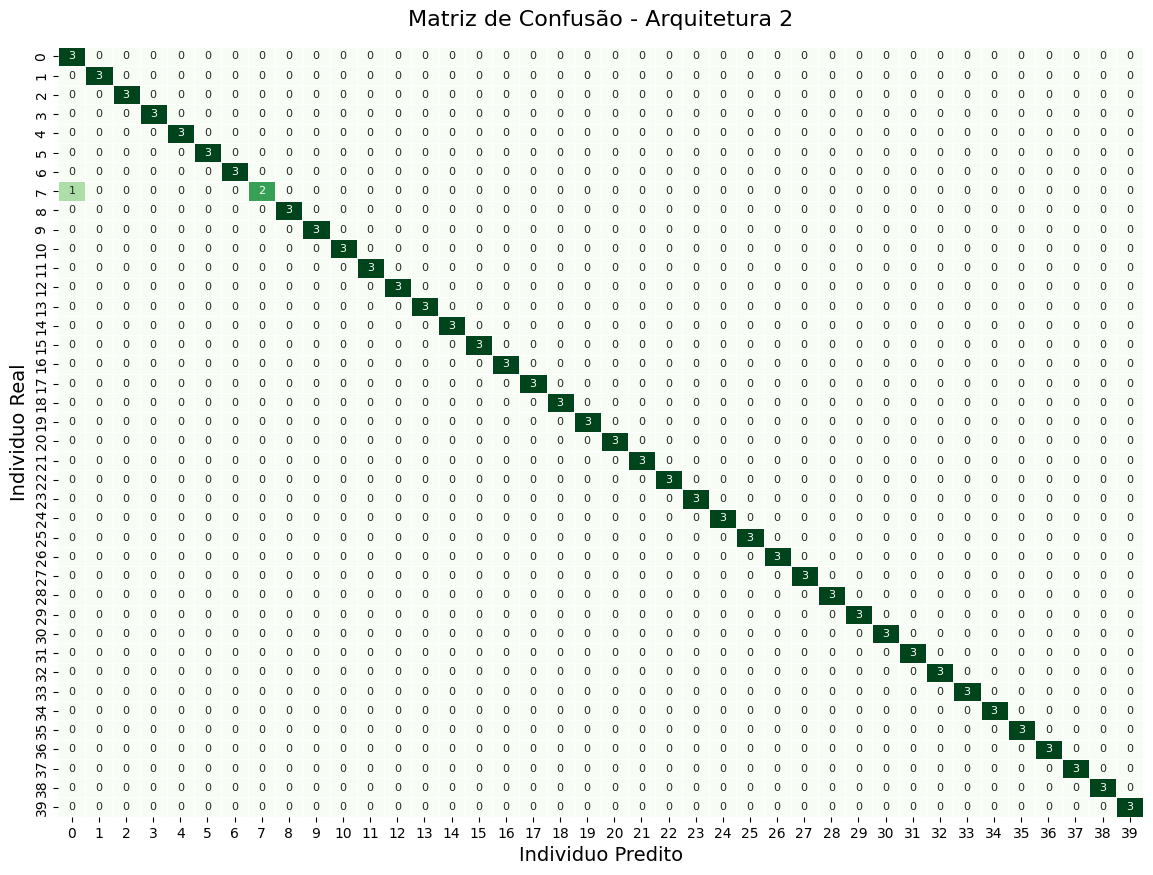

In [14]:
todas_preds_arq2 = []
todos_rotulos_arq2 = []

modelo_arq2.eval()
with torch.no_grad():
    for imagens, rotulos in loader_teste:
        imagens = imagens.to(device)
        saidas = modelo_arq2(imagens)
        _, previstos = torch.max(saidas, 1)

        todas_preds_arq2.extend(previstos.cpu().numpy())
        todos_rotulos_arq2.extend(rotulos.numpy())

print("Relatório de classificação - Arquitetura 2")
print(classification_report(todos_rotulos_arq2, todas_preds_arq2, zero_division=0))

matriz_conf_arq2 = confusion_matrix(todos_rotulos_arq2, todas_preds_arq2)

plt.figure(figsize=(14, 10))

sns.heatmap(
    matriz_conf_arq2,
    annot=True,
    fmt="d",
    cmap="Greens",
    cbar=False,
    annot_kws={"size": 8},
    linewidths=0.5,
)
plt.title("Matriz de Confusão - Arquitetura 2", fontsize=16, pad=15)
plt.ylabel("Individuo Real", fontsize=14)
plt.xlabel("Individuo Predito", fontsize=14)
plt.show()